[IPYKERNEL_LAUNCHER]INFO      Starting ANE2-Calibration-SDR v0.1.0 in America/Bogota...
[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api

[IPYKERNEL_LAUNCHER]INFO      Fetching parameters for campaign ID: 176
CAMPAIGN: FM ORIGINAL (ID: 176)
Name: FM

  [Schedule]
  - start_date: 2026-02-24T00:00:00.000Z
  - end_date: 2026-02-24T00:00:00.000Z
  - start_time: 10:30:00
  - end_time: 14:00:00
  - interval_seconds: 120

  [Configuration]
  - rbw: 1000
  - span: 20
  - antenna: 2
  - lna_gain: 40
  - vga_gain: 62
  - antenna_amp: True
  - center_freq_hz: 98000000
  - sample_rate_hz: 20000000
  - centerFrequency: 98
[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['FM original'] and nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

🚀 Starting Campaign: FM original


  ↳ Node 1: 1page [00:10, 10.47s/page]
  ↳ Node 2: 1page [00:13, 13.75s/page]
  ↳ Node 3: 1page [00:06,  6.23s/page]
  ↳ Node 4: 1page [00:06,  6.71s/page]
  ↳ Node 5: 1page [00:07,  7.18s/page]
  ↳ Node 6: 1page [00:07,  7.74s/page]
  ↳ Node 7: 1page [00:06,  6.58s/page]
  ↳ Node 8: 1page [00:01,  1.49s/page]
  ↳ Node 9: 1page [00:08,  8.07s/page]
  ↳ Node 10: 1page [00:07,  7.96s/page]

[IPYKERNEL_LAUNCHER]INFO      Finished loading data for all campaigns and nodes.


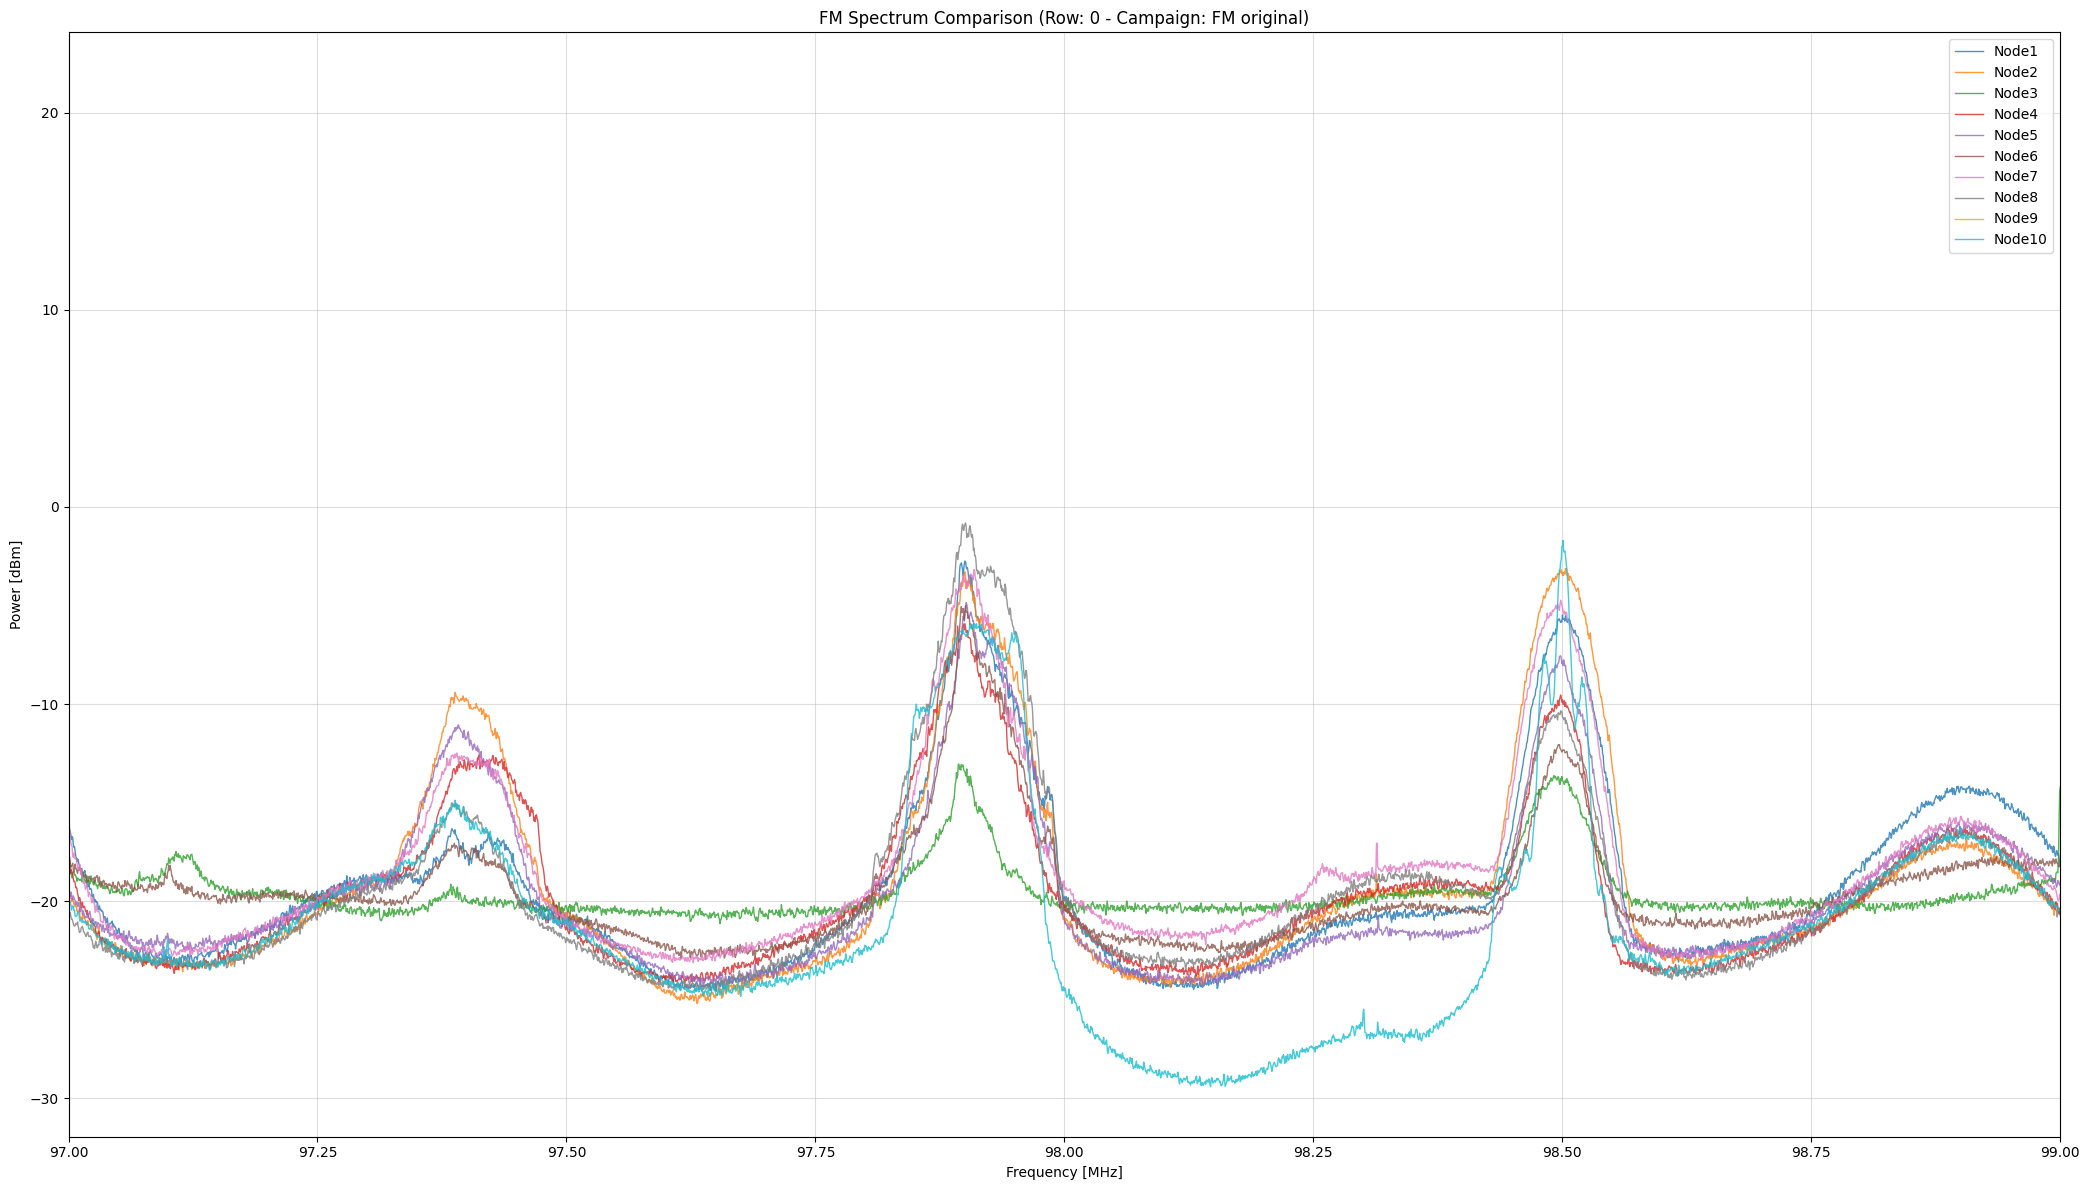

In [2]:
import cfg
import matplotlib.pyplot as plt
import numpy as np
from libs.data_request import DataRequest

log = cfg.set_logger()

camp_ids = {'FM original': 176}
target_nodes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

def main():
    log.info(f"Starting {cfg.APP_NAME} v{cfg.APP_VERSION} in {cfg.COUNTRY}...")
    dr = DataRequest(log=log, base_url=cfg.API_URL)

    # Print all campaign parameters cleanly
    print("\n" + "="*50)
    for label, c_id in camp_ids.items():
        params = dr.get_campaign_params(c_id)
        print(f"CAMPAIGN: {label.upper()} (ID: {c_id})")
        print(f"Name: {params.name}")
        
        print("\n  [Schedule]")
        for k, v in vars(params.schedule).items():
            print(f"  - {k}: {v}")
            
        print("\n  [Configuration]")
        for k, v in vars(params.config).items():
            print(f"  - {k}: {v}")
        print("="*50)

    # Load all data
    df_full = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)
    
    # Plotting configuration
    campaign_label = "FM original"
    data_nodes = df_full[campaign_label]
    ROW_PLOT = 0  

    plt.figure(figsize=(21, 12))

    for node_name, df in data_nodes.items():
        if ROW_PLOT < len(df):
            row = df.iloc[ROW_PLOT]
            pxx = np.array(row['pxx'])
            
            f_start = row['start_freq_hz'] / 1e6
            f_end = row['end_freq_hz'] / 1e6
            frequencies = np.linspace(f_start, f_end, len(pxx))
            
            plt.plot(frequencies, pxx, label=node_name, linewidth=1, alpha=0.8)

    plt.title(f"FM Spectrum Comparison (Row: {ROW_PLOT} - Campaign: {campaign_label})")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Power [dBm]")
    plt.legend(loc='best')
    plt.xlim(97, 99)
    plt.grid(True, alpha=0.42)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()